## Flujo en cadena (02 -> 03)

1. Agente 2 valida archivos nuevos y genera:

- quotes_agent_strict_events.csv
- retry_queue.parquet/csv (files a redescargar)
- state.json

2. Si retry_queue no está vacío:

- se ejecuta redescarga de esos files
- vuelve a correr Agente 2 sobre esos redescargados

3. Solo cuando retry esté limpio o congelado por límite de reintentos:

- arranca Agente 3 (stats/cobertura final incremental)

4. Agente 3 recalcula métricas usando el output validado de Agente 2:

- cobertura por ticker
- faltantes por día
- % pass / soft / hard
- resumen operativo

———

## Qué haría el Agente 3 con tu data actual

Entradas:

- C:\TSIS_Data\data\quotes_p95 (o D:\Data_polygon\quotes)
- quotes_agent_strict_events.csv
- quotes_agent_strict_state.json
- retry_queue (si existe)
- ventana oficial (official_lifecycle_compiled.csv)

Salidas:

- coverage_by_ticker.parquet/csv
- missing_days_by_ticker.parquet/csv
- quality_summary_by_ticker.parquet/csv
- run_summary.json

———

## Celdas (paso a paso, validando tú)

1. Celda A: cargar rutas y parámetros (MAX_TICKERS, DATE_FROM/TO, STRICT_ONLY=True/False).
2. Celda B: leer eventos del Agente 2 + limpiar duplicados por file (último estado).
3. Celda C: construir estado por día (PASS, SOFT_FAIL, HARD_FAIL, RETRY_PENDING).
4. Celda D: cruzar contra ventana oficial por ticker y calcular cobertura.
5. Celda E: generar tablas y gráficos (top faltantes, top warns, cobertura hist).
6. Celda F: gate de cadena:

- si hay RETRY_PENDING -> “NO cerrar corrida”
- si no hay -> “corrida cerrada”

———

## Regla clave para tu requisito de re-descarga

En Agente 3, un día/ticker con HARD_FAIL o RETRY_PENDING no cuenta cobertura hasta que:

- redescarga OK
- Agente 2 lo revalida en PASS o SOFT_FAIL

---


**Diferencia:**

**- Agente 02:**
    - evalúa archivo por archivo (calidad/estado).
    - escribe events y retry_queue.
    
**- Agente 03:**
    - consolida cobertura final por ticker/día.
    - decide si la corrida se puede cerrar.
    - verifica coherencia del sistema completo.

Por eso tiene sentido que 03 haga chequeo extra:

- files_en_events vs files_en_quotes_root
- missing_in_disk (evento dice que existe, pero no está en disco)
- missing_in_events (archivo en disco que 02 aún no validó)

No es duplicar; es auditoría de integridad del pipeline.

In [ ]:
# =========================
# Agente 03 (stats/cobertura) para la MISMA corrida del 02
# =========================

from pathlib import Path

BASE = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit")
RUN_DIR = max([p for p in BASE.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)

QUOTES_ROOT = Path(r"C:\TSIS_Data\data\quotes_p95")
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
RETRY_QUEUE_CSV = RUN_DIR / "retry_queue_quotes_strict_current.csv"

OFFICIAL_LIFECYCLE_CSV = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\data\reference\official_lifecycle_compiled.csv")
OUT_DIR = RUN_DIR / "agent03_outputs"

MIN_COVERAGE_TO_PASS = 0.95
COVERAGE_OK_STATUSES = ["PASS", "SOFT_FAIL"]

print("RUN_DIR usado:", RUN_DIR)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\036_agent3_quotes_coverage_and_causes.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

RUN_DIR usado: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260304_202248_quotes
Run summary:
{
  "events_rows_dedup": 1000,
  "tickers": 8,
  "retry_pending_files": 735,
  "hard_fail_files": 0,
  "mean_coverage_ok": 0.04413481518879127,
  "gate_status": "NO_CLOSE_RETRY_PENDING",
  "min_coverage_to_pass": 0.95,
  "out_dir": "C:\\TSIS_Data\\v1\\backtest_SmallCaps\\runs\\polygon_realtime_audit\\20260304_202248_quotes\\agent03_outputs"
}

Ticker diagnosis (por que no pasa):


,ticker,ticker_gate_status,exp_min,exp_max,expected_days,present_days,present_ok_days,missing_days_ok,coverage_ratio_ok,RETRY_PENDING,HARD_FAIL,SOFT_FAIL,cause,count,definicion
7,AAIC,LOW_COVERAGE,2021-06-25,2023-05-30,705,2,2,703,0.002837,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
1,AAC,LOW_COVERAGE,2021-09-10,2023-06-30,659,11,11,648,0.016692,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
2,AACI,LOW_COVERAGE,2026-02-17,2025-10-20,0,1,1,0,NaN,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
4,AACT,NO_CLOSE_RETRY_PENDING,2023-08-25,2025-05-30,645,12,9,636,0.013953,3,0,0,retry_pending,3.0,Archivo pendiente de reintento en retry_queue_...
5,AAGR,NO_CLOSE_RETRY_PENDING,2023-12-19,2024-09-26,283,13,5,278,0.017668,8,0,0,retry_pending,8.0,Archivo pendiente de reintento en retry_queue_...
3,AACQ,NO_CLOSE_RETRY_PENDING,2020-10-01,2021-06-24,267,34,7,260,0.026217,27,0,0,retry_pending,27.0,Archivo pendiente de reintento en retry_queue_...
6,AAI,NO_CLOSE_RETRY_PENDING,2004-01-05,2011-03-08,2620,746,186,2434,0.070992,560,0,0,retry_pending,560.0,Archivo pendiente de reintento en retry_queue_...
0,AABA,NO_CLOSE_RETRY_PENDING,2019-01-02,2019-10-02,274,181,44,230,0.160584,137,0,0,retry_pending,137.0,Archivo pendiente de reintento en retry_queue_...



Top causas globales:


,cause,cause_type,count,definicion
4,retry_pending,operational,735,Archivo pendiente de reintento en retry_queue_...
1,crossed_rows_present_but_under_threshold,warn,633,"Hay bid>ask, pero por debajo del umbral."
0,crossed_ratio_gt_threshold,issue,95,Porcentaje de bid>ask supera el umbral estricto.
2,dtype_mismatch,warn,7,Tipo de dato distinto al esperado.
3,missing_required_columns,issue,1,Faltan columnas requeridas del esquema estricto.
5,zero_rows,issue,1,Parquet leido pero sin filas.


RUN_DIR usado: C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit\20260304_202248_quotes

Leyenda de causas:


,cause,tipo,definicion
0,parquet_unreadable,HARD_FAIL,El parquet no se puede abrir/leer.
1,zero_byte_file,HARD_FAIL,Archivo de 0 bytes.
2,invalid_partition_path,HARD_FAIL,Ruta no cumple patron ticker/year/month/day/quotes.parquet.
3,zero_rows,HARD_FAIL,Parquet leido pero sin filas.
4,missing_required_columns,HARD_FAIL,Faltan columnas requeridas del esquema estricto.
5,negative_prices_any_row,HARD_FAIL,Hay filas con bid/ask negativos.
6,crossed_ratio_gt_threshold,HARD_FAIL,Porcentaje de bid>ask supera el umbral estricto.
7,dtype_mismatch,SOFT_FAIL,Tipo de dato distinto al esperado.
8,crossed_rows_present_but_under_threshold,SOFT_FAIL,"Hay bid>ask, pero por debajo del umbral."
9,soft_rule_eval_error,SOFT_FAIL,Error evaluando regla soft; archivo no necesariamente corrupto.



Resumen por severidad (events):


,severity,count
0,HARD_FAIL,96
1,PASS,265
2,SOFT_FAIL,639



Ticker diagnosis (por que no pasa):


,ticker,ticker_gate_status,RETRY_PENDING,HARD_FAIL,SOFT_FAIL,cause,count,definicion
1,AAC,LOW_COVERAGE,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
2,AACI,LOW_COVERAGE,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
7,AAIC,LOW_COVERAGE,0,0,0,low_coverage_no_validation_cause,0.0,Cobertura insuficiente en ventana esperada; si...
0,AABA,NO_CLOSE_RETRY_PENDING,137,0,0,retry_pending,137.0,Archivo pendiente de reintento en retry_queue_...
3,AACQ,NO_CLOSE_RETRY_PENDING,27,0,0,retry_pending,27.0,Archivo pendiente de reintento en retry_queue_...
4,AACT,NO_CLOSE_RETRY_PENDING,3,0,0,retry_pending,3.0,Archivo pendiente de reintento en retry_queue_...
5,AAGR,NO_CLOSE_RETRY_PENDING,8,0,0,retry_pending,8.0,Archivo pendiente de reintento en retry_queue_...
6,AAI,NO_CLOSE_RETRY_PENDING,560,0,0,retry_pending,560.0,Archivo pendiente de reintento en retry_queue_...



Cobertura temporal por ticker:


,ticker,exp_min,exp_max,expected_days,present_days,present_ok_days,missing_days_ok,coverage_ratio_ok
7,AAIC,2021-06-25,2023-05-30,705,2,2,703,0.002837
4,AACT,2023-08-25,2025-05-30,645,12,9,636,0.013953
1,AAC,2021-09-10,2023-06-30,659,11,11,648,0.016692
5,AAGR,2023-12-19,2024-09-26,283,13,5,278,0.017668
3,AACQ,2020-10-01,2021-06-24,267,34,7,260,0.026217
6,AAI,2004-01-05,2011-03-08,2620,746,186,2434,0.070992
0,AABA,2019-01-02,2019-10-02,274,181,44,230,0.160584
2,AACI,2026-02-17,2025-10-20,0,1,1,0,NaN


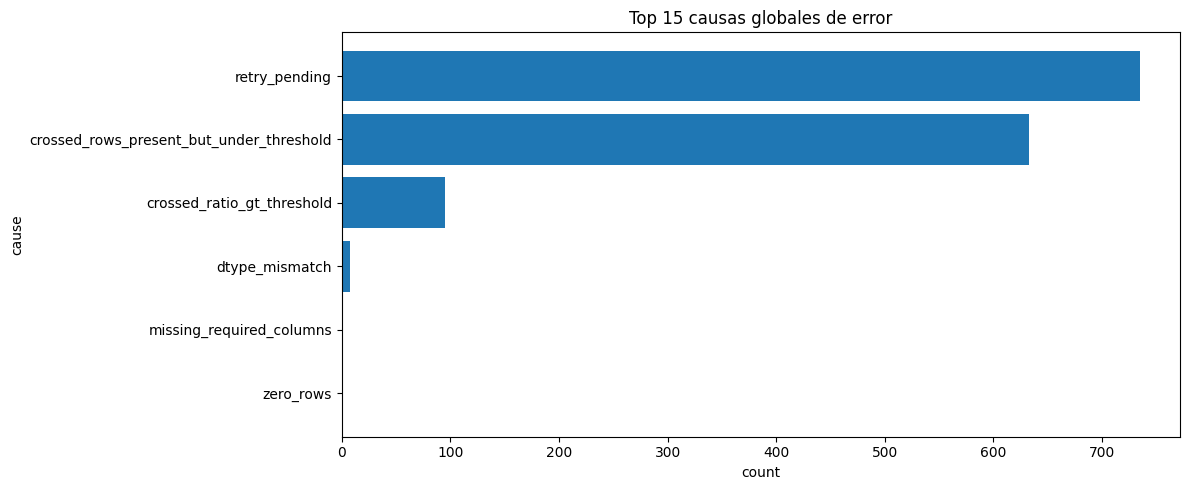

In [7]:
from pathlib import Path

BASE = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit")
RUN_DIR = max([p for p in BASE.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)

OUT_DIR = RUN_DIR / "agent03_outputs"
EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
TOP_N = 15
FIGSIZE = (12, 5)

print("RUN_DIR usado:", RUN_DIR)

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\037_agent3_diagnostics_tables_hist.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

  Ahora 036 añade causas operativas y las mete en causes_by_ticker:

  - missing_in_disk
  - missing_in_events
  - retry_pending
  - retry_frozen_exhausted

  Y 037 ya incluye esas causas en la leyenda.

  Para verlo en tu corrida, vuelve a ejecutar en este orden:

  1. 036_agent3_quotes_coverage_and_causes.py
  2. 037_agent3_diagnostics_tables_hist.py

  Si además quieres que retry_frozen_exhausted entre seguro, pásale también en 036:

  RETRY_FROZEN_CSV = RUN_DIR / "retry_frozen_quotes_strict.csv"


Metricas globales de desviacion bid>ask:


,metric,value
0,files_total,10000.000000
1,files_with_cross,6942.000000
2,files_with_cross_pct,69.420000
3,rows_total,345655218.000000
4,crossed_rows_total,1012879.000000
5,weighted_crossed_ratio_pct,0.293032
6,p00_file_crossed_ratio_pct,0.000000
7,p50_file_crossed_ratio_pct,0.044783
8,p90_file_crossed_ratio_pct,0.694751
9,p95_file_crossed_ratio_pct,1.244620



Granularidad cerca de 0 (archivos):
crossed_ratio_pct == 0: 3058 files
crossed_ratio_pct  > 0: 6942 files


,rango_crossed_ratio_pct,files,pct_files_total
0,0.10-0.50%,2502,25.020000
1,0.01-0.05%,1428,14.280000
2,0.05-0.10%,1004,10.040000
3,0.50-1.00%,699,6.990000
4,>1.00%,658,6.580000
5,0.005-0.01%,331,3.310000
6,0.001-0.005%,307,3.070000
7,0-0.001%,13,0.130000


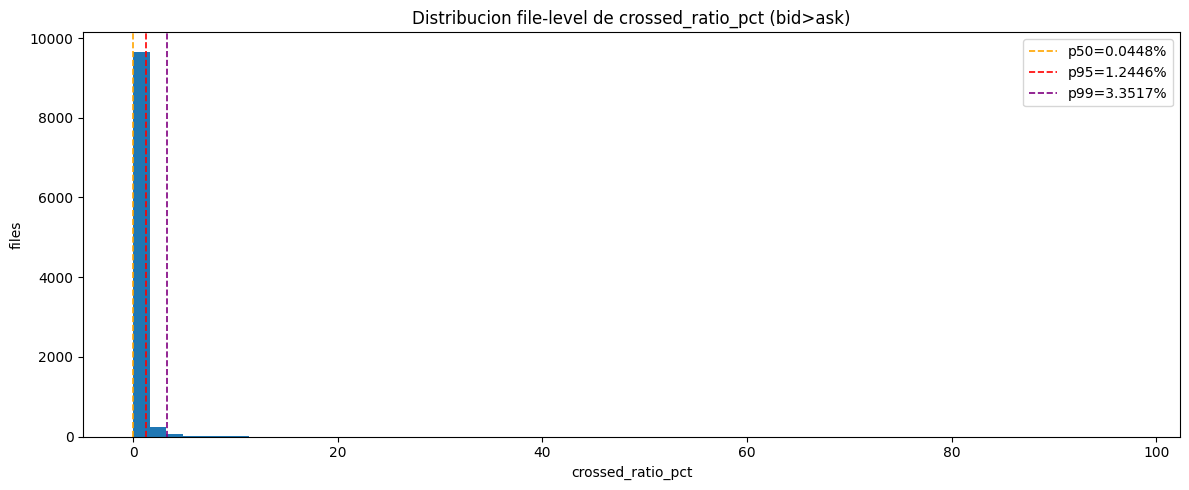

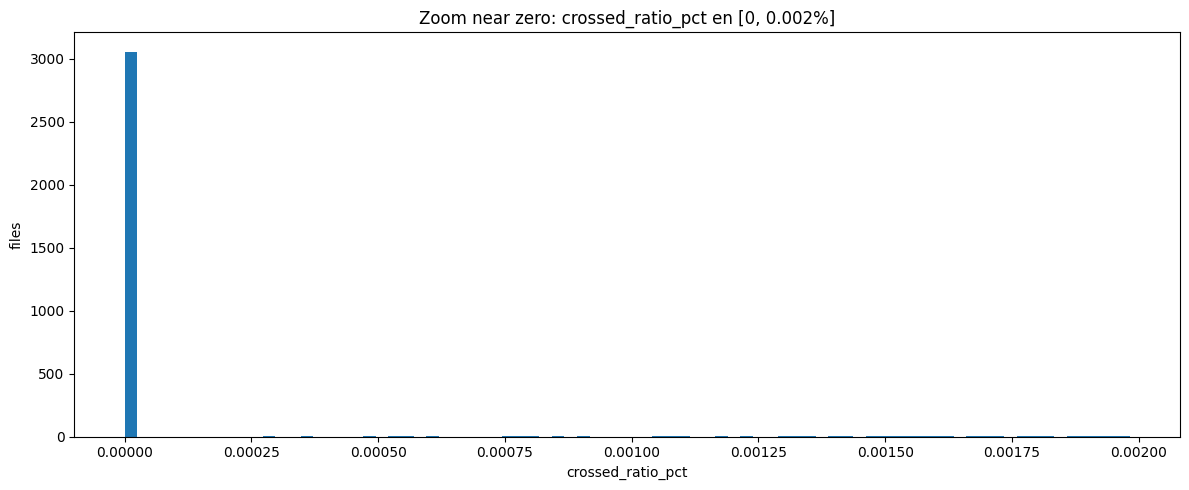

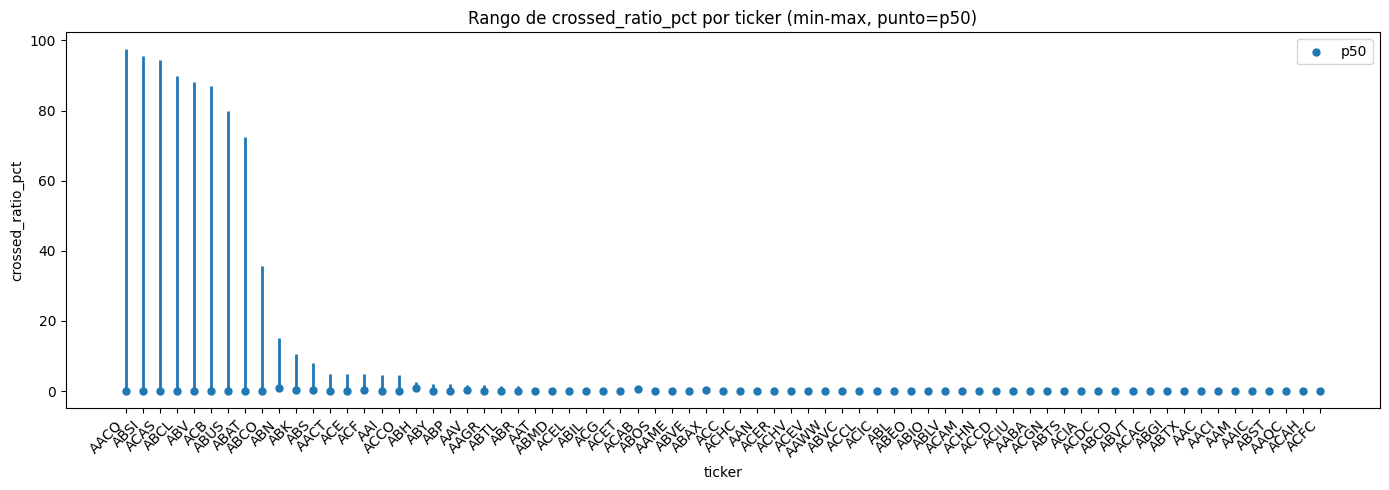


Causas globales (conteo y rango de desviacion):


,cause,cause_type,count,min_ratio,p50_ratio,p95_ratio,max_ratio
1,crossed_rows_present_but_under_threshold,warn,4210,0.000296,0.051103,0.173342,0.200000
0,crossed_ratio_gt_threshold,issue,2732,0.200188,0.495931,2.818823,97.453240
2,dtype_mismatch,warn,34,0.000000,0.000000,94.876805,97.453240
3,missing_required_columns,issue,2,0.000000,0.000000,0.000000,0.000000
4,zero_rows,issue,2,0.000000,0.000000,0.000000,0.000000


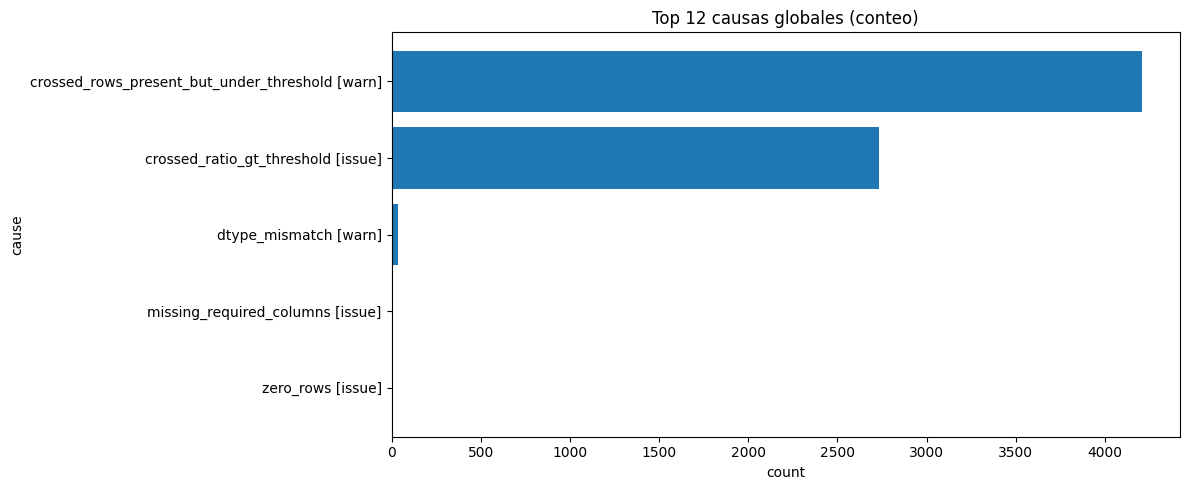

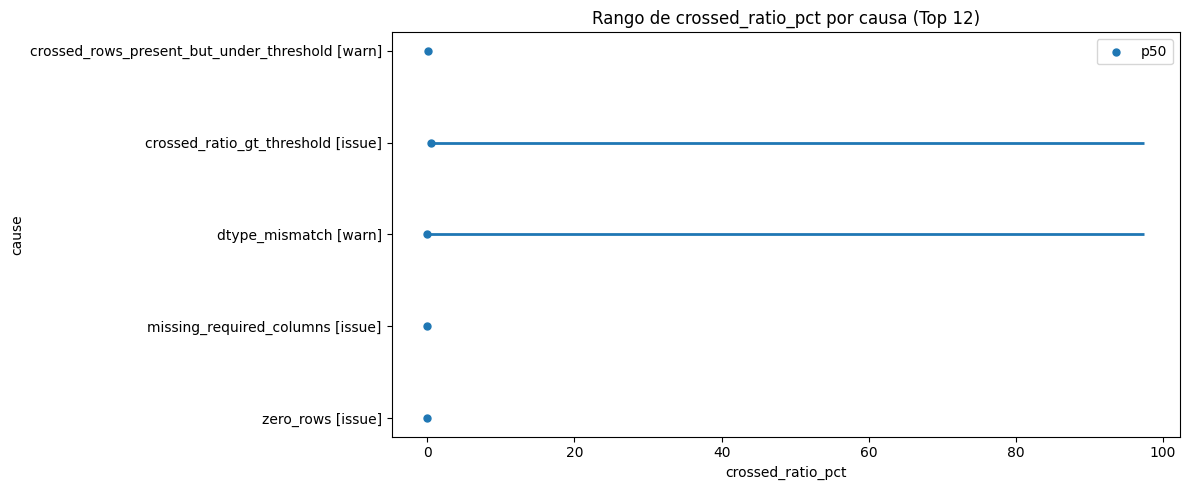

In [8]:
from pathlib import Path

RUN_ID = "20260304_192910_quotes"
RUN_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\polygon_realtime_audit") / RUN_ID

EVENTS_CSV = RUN_DIR / "quotes_agent_strict_events_current.csv"
TOP_N = 20
ZERO_ZOOM_MAX_PCT = 0.002

SCRIPT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\cell_code\00_data_certification\038_bid_ask_cross_deviation_metrics.py")
exec(SCRIPT.read_text(encoding="utf-8"), globals())

Se ven consistentes con un patrón claro:

  - Tienes muchísimos casos muy pequeños cerca de 0 (ruido/micro-anomalía esperable).
  - Pero conviven con una cola de outliers fuerte que te está rompiendo el gate (crossed_ratio_gt_threshold).
  - Las causas globales están concentradas en:
      - crossed_rows_present_but_under_threshold (volumen grande, impacto bajo)
      - crossed_ratio_gt_threshold (menos casos, impacto operativo alto)
  - dtype_mismatch, missing_required_columns, zero_rows son residuales.

  Conclusión práctica:

  - El problema real no es “todo el dataset”, sino un subconjunto de archivos/tickers con desviación extrema.
  - Tu estrategia de retry selectivo tiene sentido.
  - Para cerrar corrida, hay que atacar esos outliers (especialmente los días con ratios altos), no los casos cercanos a 0.

  Si quieres, siguiente paso útil: te saco una tabla “bloqueadores de cierre” (solo archivos con mayor contribución al RETRY_PENDING)
  para priorizar redescarga por impacto.


  Con lo que salió en tus métricas, 0.2% es conservador y todavía te deja fuera muchos días.

  Viendo tus percentiles:

  - p90 ~ 0.48%
  - p95 ~ 0.99%

  Si quieres que pasen más tickers sin abrir demasiado la mano, yo haría:

  1. Subir a 0.5% primero (paso intermedio razonable).
  2. Re-evaluar cobertura/gate.
  3. Solo si sigue muy bloqueado, probar 0.75% o 1.0% con control por outliers.

  No recomiendo saltar directo mucho más arriba, porque puedes meter días claramente dañados (ej. 2%+ y extremos tipo 97%).

  Regla práctica:

  - <=0.5%: tolerancia operativa aceptable para small/micro caps.
  - >1.0%: ya es zona de riesgo para backtest/ML si no limpias fila a fila.


**porque esta file con el o tan elevado hasta 3000?**

![](../img/037.png)

Eso suele pasar por una de estas 3 razones:

1. o es open real y hubo split/reverse split (o ajuste mal aplicado).
2. o quedó con escala equivocada (ej. centavos vs dólares).
3. Ese parquet está corrupto/mapeado mal (columnas desplazadas en esa descarga).

Para micro/small caps, ver un o ~3000 normalmente es sospechoso si días cercanos están en rango bajo.

Cómo decidir rápido:

- Compara ese día con day-1 y day+1 del mismo ticker.
- Revisa splits.parquet en esa fecha.
- Si no hay split y el salto es extremo, márcalo como archivo malo y re-descárgalo.

Regla práctica que te recomiendo:

- Si o salta >50x respecto a la mediana de los últimos 20 días y no hay split, tratar como HARD_FAIL por anomalía de precio.


- Ese p90/p95 era sobre distribución de archivos de crossed_ratio_pct.
- Subir umbral (ej. a 0.5%) es una decisión operativa de cobertura para no bloquear demasiados días.

Pero eso no implica aceptar valores absurdos de precio (o=3000) ni outliers extremos de calidad.
Son dos controles distintos:

1. Control microestructura: bid > ask (crossed_ratio_pct).
2. Control de precio/anomalías OHLC: saltos imposibles, escalado, splits no ajustados.

Entonces:

- Sí, puedes subir crossed_ratio moderadamente para ganar cobertura.
- Y a la vez mantener/fortalecer filtros de anomalía de precio para no contaminar backtest/ML.